# Understanding Box-Cox Plots

The **Box-Cox transformation** is a family of power transformations parameterised by λ:

```
y(λ) = (x^λ − 1) / λ    if λ ≠ 0
y(λ) = ln(x)            if λ = 0
```

It includes common transforms as special cases: λ=1 (identity), λ=0 (log), λ=0.5 (square root), λ=−1 (reciprocal).

Two diagnostic plots are used for Box-Cox:

1. **Box-Cox Linearity Plot** — plots the correlation between y and x^λ vs λ; the optimal λ is the one that maximises the linear fit between x and y.
2. **Box-Cox Normality Plot** — plots the log-likelihood (or correlation coefficient from a normal Q-Q plot) vs λ; the optimal λ makes the transformed data most normally distributed.

**Goal:** Find the λ that transforms x to make it either (a) linearly related to y, or (b) normally distributed — whichever is appropriate for the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

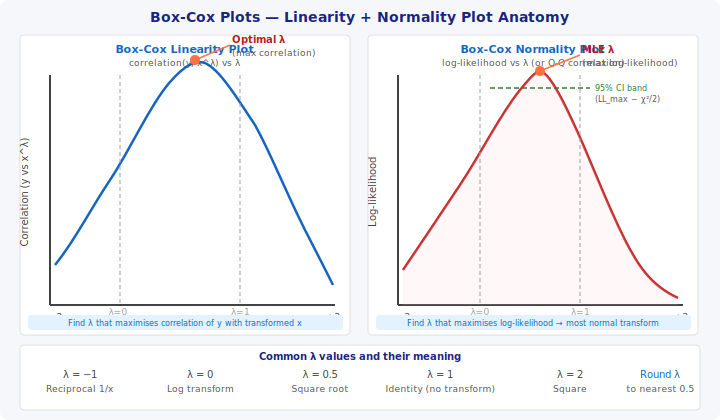

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="420"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="420" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Box-Cox Plots — Linearity + Normality Plot Anatomy</text>

  <!-- ── LEFT: Box-Cox Linearity Plot ── -->
  <rect x="20" y="35" width="330" height="300" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="185" y="53" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Box-Cox Linearity Plot</text>
  <text x="185" y="66" text-anchor="middle" font-size="9" fill="#555">correlation(y, x^λ) vs λ</text>

  <!-- Axes -->
  <line x1="50"  y1="305" x2="335" y2="305" stroke="#424242" stroke-width="2"/>
  <line x1="50"  y1="305" x2="50"  y2="75"  stroke="#424242" stroke-width="2"/>
  <text x="192" y="325" text-anchor="middle" font-size="10" fill="#424242">λ (power parameter)</text>
  <text x="28" y="192" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 28 192)">Correlation (y vs x^λ)</text>

  <!-- Correlation curve (peaks around λ=0.3) -->
  <path d="M 55,265 C 75,240 90,210 110,180 C 130,150 150,105 170,82 C 185,65 195,60 205,63
           C 220,70 235,95 255,125 C 270,152 285,190 305,230 C 318,255 328,275 333,285"
        fill="none" stroke="#1565C0" stroke-width="2.5"/>

  <!-- Peak annotation -->
  <circle cx="195" cy="60" r="5" fill="#FF7043"/>
  <line x1="195" y1="60" x2="230" y2="45" stroke="#FF7043" stroke-width="1.5"/>
  <text x="232" y="43" font-size="10" font-weight="bold" fill="#B71C1C">Optimal λ</text>
  <text x="232" y="56" font-size="9" fill="#555">(max correlation)</text>

  <!-- λ = 0 (log) reference -->
  <line x1="120" y1="75" x2="120" y2="305" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="118" y="315" text-anchor="middle" font-size="9" fill="#9E9E9E">λ=0</text>
  <text x="118" y="325" text-anchor="middle" font-size="8" fill="#9E9E9E">(log)</text>

  <!-- λ = 1 (identity) reference -->
  <line x1="240" y1="75" x2="240" y2="305" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="240" y="315" text-anchor="middle" font-size="9" fill="#9E9E9E">λ=1</text>
  <text x="240" y="325" text-anchor="middle" font-size="8" fill="#9E9E9E">(identity)</text>

  <!-- λ tick labels -->
  <text x="55"  y="320" text-anchor="middle" font-size="9" fill="#424242">−2</text>
  <text x="333" y="320" text-anchor="middle" font-size="9" fill="#424242">+2</text>

  <!-- Takeaway left -->
  <rect x="28" y="315" width="315" height="15" fill="#E3F2FD" rx="3"/>
  <text x="185" y="326" text-anchor="middle" font-size="8" fill="#1565C0">
    Find λ that maximises correlation of y with transformed x
  </text>

  <!-- ── RIGHT: Box-Cox Normality Plot ── -->
  <rect x="368" y="35" width="330" height="300" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="533" y="53" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Box-Cox Normality Plot</text>
  <text x="533" y="66" text-anchor="middle" font-size="9" fill="#555">log-likelihood vs λ (or Q-Q correlation)</text>

  <!-- Axes -->
  <line x1="398" y1="305" x2="683" y2="305" stroke="#424242" stroke-width="2"/>
  <line x1="398" y1="305" x2="398" y2="75"  stroke="#424242" stroke-width="2"/>
  <text x="540" y="325" text-anchor="middle" font-size="10" fill="#424242">λ (power parameter)</text>
  <text x="376" y="192" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 376 192)">Log-likelihood</text>

  <!-- Log-likelihood curve (peaks around λ=0.2) -->
  <path d="M 403,270 C 420,245 440,215 460,185 C 480,155 500,115 520,90
           C 530,78 535,72 540,71 C 548,73 558,90 572,120 C 590,158 605,200 625,240
           C 638,265 650,285 678,298"
        fill="none" stroke="#C62828" stroke-width="2.5"/>
  <path d="M 403,270 C 420,245 440,215 460,185 C 480,155 500,115 520,90
           C 530,78 535,72 540,71 C 548,73 558,90 572,120 C 590,158 605,200 625,240
           C 638,265 650,285 678,298 L 678,305 L 403,305 Z"
        fill="#FFCDD2" opacity="0.15"/>

  <!-- Peak annotation -->
  <circle cx="540" cy="71" r="5" fill="#FF7043"/>
  <line x1="540" y1="71" x2="580" y2="55" stroke="#FF7043" stroke-width="1.5"/>
  <text x="582" y="53" font-size="10" font-weight="bold" fill="#B71C1C">MLE λ</text>
  <text x="582" y="66" font-size="9" fill="#555">(max log-likelihood)</text>

  <!-- 95% CI band -->
  <line x1="490" y1="88" x2="590" y2="88" stroke="#2E7D32" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="595" y="91" font-size="8" fill="#2E7D32">95% CI band</text>
  <text x="595" y="102" font-size="8" fill="#555">(LL_max − χ²/2)</text>

  <!-- λ references -->
  <line x1="480" y1="75" x2="480" y2="305" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="480" y="315" text-anchor="middle" font-size="9" fill="#9E9E9E">λ=0</text>
  <line x1="580" y1="75" x2="580" y2="305" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="580" y="315" text-anchor="middle" font-size="9" fill="#9E9E9E">λ=1</text>

  <text x="403" y="320" text-anchor="middle" font-size="9" fill="#424242">−2</text>
  <text x="681" y="320" text-anchor="middle" font-size="9" fill="#424242">+2</text>

  <!-- Takeaway right -->
  <rect x="376" y="315" width="315" height="15" fill="#E3F2FD" rx="3"/>
  <text x="533" y="326" text-anchor="middle" font-size="8" fill="#1565C0">
    Find λ that maximises log-likelihood → most normal transform
  </text>

  <!-- Lambda table -->
  <rect x="20" y="345" width="680" height="65" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="360" y="360" text-anchor="middle" font-size="10" font-weight="bold" fill="#1A237E">Common λ values and their meaning</text>
  <text x="80"  y="378" text-anchor="middle" font-size="10" fill="#424242">λ = −1</text>
  <text x="80"  y="392" text-anchor="middle" font-size="9"  fill="#555">Reciprocal 1/x</text>
  <text x="200" y="378" text-anchor="middle" font-size="10" fill="#424242">λ = 0</text>
  <text x="200" y="392" text-anchor="middle" font-size="9"  fill="#555">Log transform</text>
  <text x="320" y="378" text-anchor="middle" font-size="10" fill="#424242">λ = 0.5</text>
  <text x="320" y="392" text-anchor="middle" font-size="9"  fill="#555">Square root</text>
  <text x="440" y="378" text-anchor="middle" font-size="10" fill="#424242">λ = 1</text>
  <text x="440" y="392" text-anchor="middle" font-size="9"  fill="#555">Identity (no transform)</text>
  <text x="570" y="378" text-anchor="middle" font-size="10" fill="#424242">λ = 2</text>
  <text x="570" y="392" text-anchor="middle" font-size="9"  fill="#555">Square</text>
  <text x="660" y="378" text-anchor="middle" font-size="10" fill="#1565C0">Round λ</text>
  <text x="660" y="392" text-anchor="middle" font-size="9"  fill="#555">to nearest 0.5</text>
</svg>
"""
display(SVG(_svg))

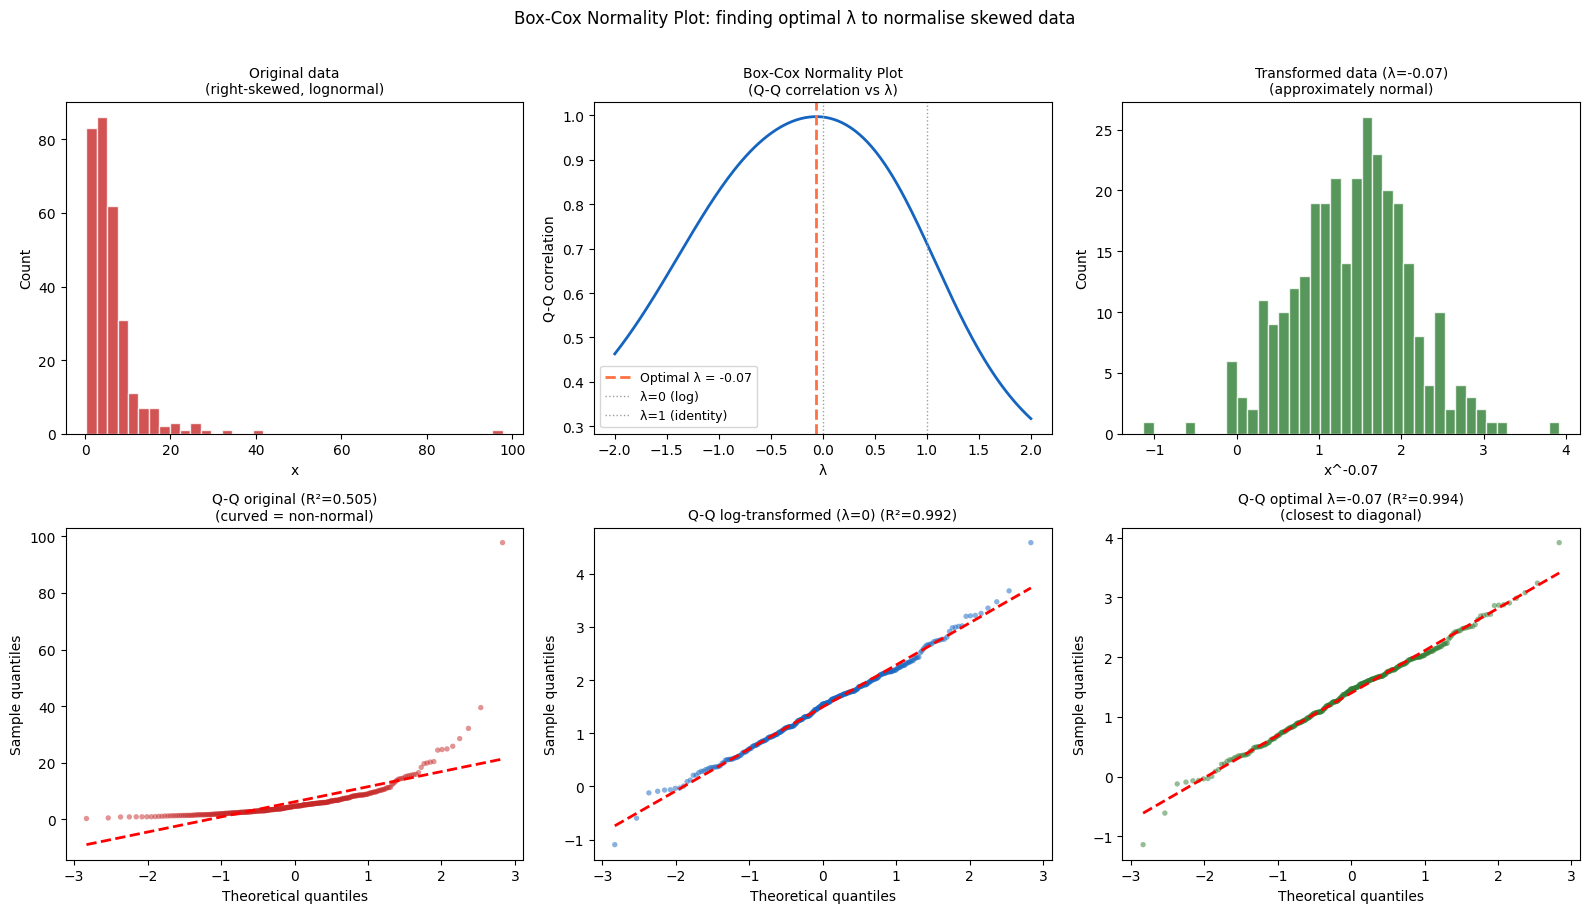

Optimal λ = -0.070 (rounded → use λ = 0.0)


In [3]:
np.random.seed(42)

# Generate right-skewed data (lognormal)
x_skew = np.random.lognormal(mean=1.5, sigma=0.8, size=300)

# ── Box-Cox Normality Plot ──
lambdas = np.linspace(-2, 2, 200)

def boxcox_transform(x, lam):
    if abs(lam) < 1e-6:
        return np.log(x)
    return (x**lam - 1) / lam

def qqcorr(x):
    """Correlation between sample quantiles and theoretical normal quantiles."""
    n = len(x)
    p = (np.arange(1, n+1) - 0.375) / (n + 0.25)
    theoretical = stats.norm.ppf(p)
    return np.corrcoef(np.sort(x), theoretical)[0, 1]

correlations = [qqcorr(boxcox_transform(x_skew, lam)) for lam in lambdas]
optimal_lambda = lambdas[np.argmax(correlations)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Panel 1: original data histogram
axes[0, 0].hist(x_skew, bins=40, color='#C62828', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Original data\n(right-skewed, lognormal)', fontsize=10)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('Count')

# Panel 2: Box-Cox normality plot
axes[0, 1].plot(lambdas, correlations, color='#1565C0', linewidth=2)
axes[0, 1].axvline(optimal_lambda, color='#FF7043', linewidth=2, linestyle='--',
                   label=f'Optimal λ = {optimal_lambda:.2f}')
axes[0, 1].axvline(0, color='#9E9E9E', linewidth=1, linestyle=':', label='λ=0 (log)')
axes[0, 1].axvline(1, color='#9E9E9E', linewidth=1, linestyle=':', label='λ=1 (identity)')
axes[0, 1].set_title('Box-Cox Normality Plot\n(Q-Q correlation vs λ)', fontsize=10)
axes[0, 1].set_xlabel('λ')
axes[0, 1].set_ylabel('Q-Q correlation')
axes[0, 1].legend(fontsize=9)

# Panel 3: transformed data histogram (optimal λ)
x_transformed = boxcox_transform(x_skew, optimal_lambda)
axes[0, 2].hist(x_transformed, bins=40, color='#2E7D32', edgecolor='white', alpha=0.8)
axes[0, 2].set_title(f'Transformed data (λ={optimal_lambda:.2f})\n(approximately normal)', fontsize=10)
axes[0, 2].set_xlabel(f'x^{optimal_lambda:.2f}')
axes[0, 2].set_ylabel('Count')

# Normal Q-Q plots for comparison
(osm_orig, osr_orig), (s_o, i_o, r_o) = stats.probplot(x_skew, dist='norm')
axes[1, 0].scatter(osm_orig, osr_orig, color='#C62828', alpha=0.5, s=15, edgecolors='none')
axes[1, 0].plot(osm_orig, s_o*np.array(osm_orig)+i_o, 'r--', linewidth=2)
axes[1, 0].set_title(f'Q-Q original (R²={r_o**2:.3f})\n(curved = non-normal)', fontsize=10)
axes[1, 0].set_xlabel('Theoretical quantiles')
axes[1, 0].set_ylabel('Sample quantiles')

(osm_log, osr_log), (s_l, i_l, r_l) = stats.probplot(np.log(x_skew), dist='norm')
axes[1, 1].scatter(osm_log, osr_log, color='#1565C0', alpha=0.5, s=15, edgecolors='none')
axes[1, 1].plot(osm_log, s_l*np.array(osm_log)+i_l, 'r--', linewidth=2)
axes[1, 1].set_title(f'Q-Q log-transformed (λ=0) (R²={r_l**2:.3f})', fontsize=10)
axes[1, 1].set_xlabel('Theoretical quantiles')
axes[1, 1].set_ylabel('Sample quantiles')

(osm_opt, osr_opt), (s_t, i_t, r_t) = stats.probplot(x_transformed, dist='norm')
axes[1, 2].scatter(osm_opt, osr_opt, color='#2E7D32', alpha=0.5, s=15, edgecolors='none')
axes[1, 2].plot(osm_opt, s_t*np.array(osm_opt)+i_t, 'r--', linewidth=2)
axes[1, 2].set_title(f'Q-Q optimal λ={optimal_lambda:.2f} (R²={r_t**2:.3f})\n(closest to diagonal)', fontsize=10)
axes[1, 2].set_xlabel('Theoretical quantiles')
axes[1, 2].set_ylabel('Sample quantiles')

plt.suptitle('Box-Cox Normality Plot: finding optimal λ to normalise skewed data', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print(f"Optimal λ = {optimal_lambda:.3f} (rounded → use λ = {round(optimal_lambda*2)/2:.1f})")

## Key Takeaways

| | |
|---|---|
| **Purpose** | Find the power transform λ that normalises or linearises data |
| **Box-Cox Normality Plot** | y-axis = Q-Q correlation vs λ → pick λ at peak |
| **Box-Cox Linearity Plot** | y-axis = correlation(y, x^λ) vs λ → pick λ for best linear fit |
| **λ = 0** | Log transform (most common for right-skewed, positive data) |
| **λ = 0.5** | Square root (count data, moderate skew) |
| **λ = 1** | No transform needed (data is already appropriate) |
| **Round λ** | Round to nearest 0.5 for interpretability (e.g., 0.12 → use log) |
| **Requirement** | Data must be strictly positive (x > 0) for Box-Cox |
| **scipy** | `scipy.stats.boxcox(x)` returns transformed data + optimal λ |
| **vs Yeo-Johnson** | Yeo-Johnson extends Box-Cox to zero and negative values |